# CMPE 401 Project 1: Colab runner

Runs one experiment from `configs/experiments.yaml` end to end: train, evaluate, and plot.

1. **Runtime > Change runtime type > GPU** (T4 or better).
2. Set `RUN` below and run all cells.
3. If Colab disconnects, reconnect and **run all again**. Training resumes from the last epoch saved on Google Drive.
4. When it finishes, download `MyDrive/cmpe401/results/<RUN>/` and add it to the repo's `results/` folder.

In [1]:
RUN = "baseline"   # baseline | p3_imgsz960 | p4_cos_lr | p4_regularize | p5_yolov8n
SMOKE_TEST = False # True = 1 epoch on 5% of the data, to check the pipeline before a long run

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
DRIVE = "/content/drive/MyDrive/cmpe401"
os.environ["RUNS_DIR"] = f"{DRIVE}/runs"        # weights + checkpoints (survive disconnects)
os.environ["RESULTS_DIR"] = f"{DRIVE}/results"  # CSVs, plots, metrics to commit to the repo
os.makedirs(os.environ["RUNS_DIR"], exist_ok=True)
os.makedirs(os.environ["RESULTS_DIR"], exist_ok=True)

Mounted at /content/drive


In [3]:
%cd /content
!test -d repo || git clone https://github.com/EzraKrause04/CMPE-401---Instructor-Defined-Project-1.git repo
%cd /content/repo
!git pull -q
!pip install -q -r requirements.txt
!nvidia-smi --query-gpu=name,memory.total --format=csv

/content
Cloning into 'repo'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 50 (delta 13), reused 21 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 219.59 KiB | 24.40 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/repo
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 9.8 MB/s eta 0:00:00
name, memory.total [MiB]
Tesla T4, 15360 MiB


In [4]:
# VisDrone (~2 GB) downloads to fast local disk on first use in each session (a few minutes).
!yolo settings datasets_dir=/content/datasets

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
✅ Updated 'datasets_dir=/content/datasets'
JSONDict("/root/.config/Ultralytics/settings.json"):
{
  "settings_version": "0.0.8",
  "datasets_dir": "/content/datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb",
  "sync": true,
  "api_key": "",
  "openai_api_key": "",
  "clearml": true,
  "comet": true,
  "dvc": true,
  "mlflow": true,
  "raytune": true,
  "tensorboard": false,
  "wandb": false,
  "vscode_msg": true,
  "openvino_msg": true
}
💡 Learn more about Ultralytics Settings at https://docs.ultralytics.com/usage/settings


In [5]:
if SMOKE_TEST:
    !python src/train.py {RUN} --epochs 1 --fraction 0.05
else:
    !python src/train.py {RUN}

== baseline (Part I): YOLO26n, default augmentation, 640 px
baseline already finished; skipping training (delete /content/drive/MyDrive/cmpe401/runs/baseline to retrain)
Copied run artifacts to /content/drive/MyDrive/cmpe401/results/baseline


In [6]:
if not SMOKE_TEST:
    !python src/evaluate.py {RUN} --split val
    !python src/evaluate.py {RUN} --split test
    !python src/plot_curves.py {RUN}

Ultralytics 8.4.162 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,786 parameters, 0 gradients, 5.3 GFLOPs

WARNING ⚠️ Dataset 'VisDrone.yaml' images not found, missing path '/content/datasets/VisDrone/images/val'
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-val.zip to /content/datasets/VisDrone/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 354.8files/s 3.1s
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-test-dev.zip to /content/datasets/VisDrone/VisDrone2019-DET-test-dev...: 100% ━━━━━━━━━━━━ 3223/3223 646.3files/s 5.0s
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-train.zip to /content/datasets/VisDrone/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 12945/12945 1.3Kfiles/s 9.8s
Converting train: ━━━━━━━━━━━━ 6471 2.4Kit/s 3.6s
Converting val: ━━━━━━━━━━━━ 548 1.5Kit/s 0.2s
Converting test: ━━━━━━━━━━━━ 1610 2.0Kit/s 0.7s
Dataset download success ✅ (64.9s), saved to /content/datasets

val: Fast im

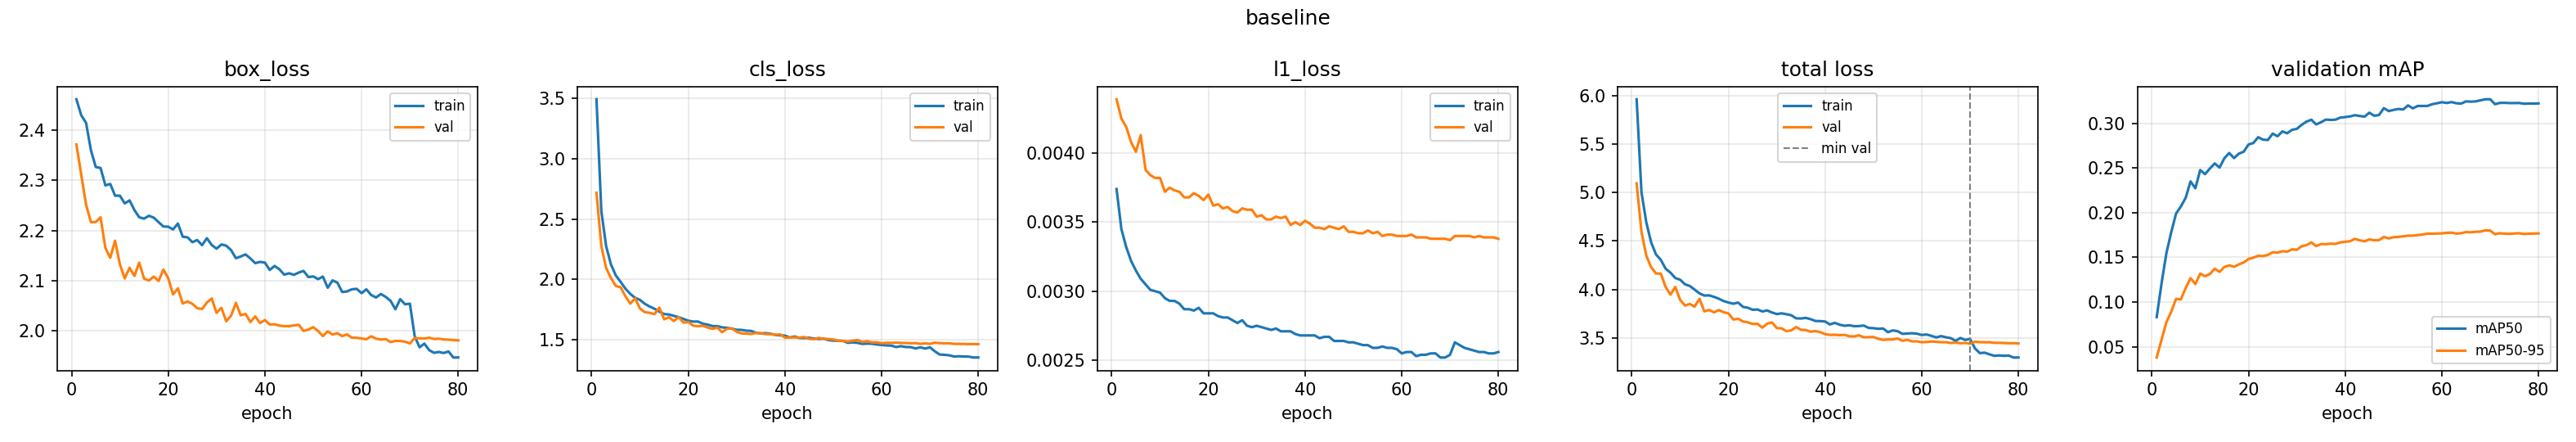

In [7]:
from IPython.display import Image, display
if not SMOKE_TEST:
    display(Image(f"{os.environ['RESULTS_DIR']}/{RUN}/loss_curves.png"))